### Mechanization Index Reliability Testing

This section valuates the internal consistency of the machinery indicators used to construct the mechanization index using Cronbach's alpha.

### 1. Data Loading and Setup

In [14]:
import numpy as np
import pandas as pd

In [15]:
df = pd.read_csv("../../data/index/mechanization_index_input.csv")

df.head(5)

,an,judet,emig_masc_nr,emig_fem_nr,emigranti_total_nr,emig_15_64_nr,imig_masc_nr,imig_fem_nr,imigranti_total_nr,imigranti_15_64_nr,...,tractoare_nr,pluguri_nr,semanatori_mecanice_nr,masini_stropit_prafuit_mecanice_nr,combine_cereale_nr,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,masini_stropit_1000ha,combine_1000ha
0,2012,Alba,143,144,287,222,43,33,76,66,...,3655,3115,1560,177,574,57.017612,48.593670,24.335835,2.761181,8.954339
1,2013,Alba,104,158,262,224,53,41,94,83,...,4105,3407,1560,177,597,65.047221,53.986816,24.719528,2.804716,9.459973
2,2014,Alba,77,84,161,141,50,44,94,83,...,4113,3407,1560,177,598,62.017491,51.372135,23.522316,2.668878,9.016888
3,2015,Alba,84,109,193,175,61,45,106,88,...,4181,3448,1584,177,620,59.600006,49.151117,22.579863,2.523129,8.838078
4,2016,Alba,127,161,288,268,47,72,119,105,...,4227,3448,1584,177,633,63.317306,51.648467,23.727138,2.651328,9.481868


In [16]:
df.columns

Index(['an', 'judet', 'emig_masc_nr', 'emig_fem_nr', 'emigranti_total_nr',
       'emig_15_64_nr', 'imig_masc_nr', 'imig_fem_nr', 'imigranti_total_nr',
       'imigranti_15_64_nr', 'populatie_15_64', 'populatie_rurala',
       'populatie_totala', 'pondere_rurala', 'rata_emig_def', 'rata_imig_def',
       'rata_emig_15_64', 'rata_imig_15_64', 'intensitate_migratie',
       'sup_grau_ha', 'sup_orz_orzoaica_ha', 'sup_porumb_boabe_ha',
       'sup_floarea_soarelui_ha', 'sup_rapita_ha', 'sup_soia_boabe_ha',
       'sup_totala_cultivata_ha', 'pondere_grau', 'pondere_orz_orzoaica',
       'pondere_porumb_boabe', 'pondere_floarea_soarelui', 'pondere_rapita',
       'pondere_soia_boabe', 'prod_grau_tone', 'prod_orz_orzoaica_tone',
       'prod_porumb_boabe_tone', 'prod_floarea_soarelui_tone',
       'prod_rapita_tone', 'prod_soia_boabe_tone', 'yield_grau',
       'yield_orz_orzoaica', 'yield_porumb_boabe', 'yield_floarea_soarelui',
       'yield_rapita', 'yield_soia_boabe', 'ocupati_total_nr',


### 2. Data Quality Checks

In [17]:
items = [
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha",
    "masini_stropit_1000ha"
]

In [18]:
for col in items:
    print(col, col in df.columns)

tractoare_1000ha True
pluguri_1000ha True
semanatori_1000ha True
combine_1000ha True
masini_stropit_1000ha True


In [19]:
df[items].isna().sum()

tractoare_1000ha         0
pluguri_1000ha           0
semanatori_1000ha        0
combine_1000ha           0
masini_stropit_1000ha    0
dtype: int64

### 3. Internal Consistency of Machinery Indicators

In [20]:
df_alpha = df[items].dropna()

print("Randuri inițiale:", len(df))
print("Randuri folosite pentru Cronbach alpha:", len(df_alpha))

Randuri inițiale: 451
Randuri folosite pentru Cronbach alpha: 451


In [21]:
df_alpha_z = (df_alpha - df_alpha.mean()) / df_alpha.std(ddof=1)

In [22]:
df_alpha_z.describe()

,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha,masini_stropit_1000ha
count,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02,4.510000e+02
mean,6.301931e-17,-1.339160e-16,-1.220999e-16,1.260386e-16,-2.363224e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-7.554397e-01,-8.469938e-01,-1.202333e+00,-1.140652e+00,-7.036290e-01
25%,-6.051270e-01,-6.602356e-01,-7.442859e-01,-7.196767e-01,-5.666743e-01
50%,-4.185426e-01,-4.582834e-01,-2.579429e-01,-3.304090e-01,-4.126763e-01
75%,2.267947e-01,2.950298e-01,4.553411e-01,5.039215e-01,9.423107e-02
max,5.534949e+00,4.677276e+00,5.153321e+00,4.535036e+00,6.747696e+00


#### 3.1 Cronbach's Alpha

In [23]:
def cronbach_alpha(data):
    data = data.astype(float)
    n_items = data.shape[1]
    
    item_variances = data.var(axis=0, ddof=1)
    total_score = data.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    
    alpha = (n_items / (n_items - 1)) * (
        1 - item_variances.sum() / total_variance
    )
    
    return alpha

In [24]:
alpha = cronbach_alpha(df_alpha_z)

print("Cronbach's alpha:", round(alpha, 3))

Cronbach's alpha: 0.901


#### 3.2 Item-Deletion Analysis

In [25]:
for item in items:
    reduced_items = [x for x in items if x != item]
    alpha_reduced = cronbach_alpha(df_alpha_z[reduced_items])
    print(f"Fără {item}: alpha = {round(alpha_reduced, 3)}")

Fără tractoare_1000ha: alpha = 0.859
Fără pluguri_1000ha: alpha = 0.851
Fără semanatori_1000ha: alpha = 0.859
Fără combine_1000ha: alpha = 0.862
Fără masini_stropit_1000ha: alpha = 0.949


#### 3.3 Correlation Matrix

In [26]:
corr_matrix = df_alpha_z.corr()
corr_matrix

,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha,masini_stropit_1000ha
tractoare_1000ha,1.000000,0.963633,0.797306,0.752604,0.320810
pluguri_1000ha,0.963633,1.000000,0.874054,0.769781,0.318841
semanatori_1000ha,0.797306,0.874054,1.000000,0.776517,0.387827
combine_1000ha,0.752604,0.769781,0.776517,1.000000,0.495121
masini_stropit_1000ha,0.320810,0.318841,0.387827,0.495121,1.000000


In [27]:
print(corr_matrix.round(2))

                       tractoare_1000ha  pluguri_1000ha  semanatori_1000ha  \
tractoare_1000ha                   1.00            0.96               0.80   
pluguri_1000ha                     0.96            1.00               0.87   
semanatori_1000ha                  0.80            0.87               1.00   
combine_1000ha                     0.75            0.77               0.78   
masini_stropit_1000ha              0.32            0.32               0.39   

                       combine_1000ha  masini_stropit_1000ha  
tractoare_1000ha                 0.75                   0.32  
pluguri_1000ha                   0.77                   0.32  
semanatori_1000ha                0.78                   0.39  
combine_1000ha                   1.00                   0.50  
masini_stropit_1000ha            0.50                   1.00  


###

### 4. PCA Assessment of Alternative Index Specifications

In [28]:
items_5 = [
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha",
    "masini_stropit_1000ha"
]

items_4 = [
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha"
]

In [29]:
df_pca_5 = df[items_5].dropna()
df_pca_4 = df[items_4].dropna()

print("Observații PCA 5 utilaje:", len(df_pca_5))
print("Observații PCA 4 utilaje:", len(df_pca_4))

Observații PCA 5 utilaje: 451
Observații PCA 4 utilaje: 451


In [30]:
from sklearn.preprocessing import StandardScaler

scaler_5 = StandardScaler()
X5_scaled = scaler_5.fit_transform(df_pca_5)

scaler_4 = StandardScaler()
X4_scaled = scaler_4.fit_transform(df_pca_4)

#### 4.1 Five-Indicator Specification

In [31]:
from sklearn.decomposition import PCA

pca_5 = PCA()
pca_5.fit(X5_scaled)

explained_5 = pd.DataFrame({
    "componenta": [f"PC{i+1}" for i in range(len(items_5))],
    "varianta_explicata": pca_5.explained_variance_ratio_,
    "varianta_explicata_pct": pca_5.explained_variance_ratio_ * 100,
    "varianta_cumulata_pct": np.cumsum(pca_5.explained_variance_ratio_) * 100
})

explained_5

,componenta,varianta_explicata,varianta_explicata_pct,varianta_cumulata_pct
0,PC1,0.736892,73.689208,73.689208
1,PC2,0.167326,16.732582,90.421790
2,PC3,0.050784,5.078399,95.500189
3,PC4,0.040221,4.022073,99.522261
4,PC5,0.004777,0.477739,100.000000


#### 4.2 Four-Indicator Specification

In [32]:
pca_4 = PCA()
pca_4.fit(X4_scaled)

explained_4 = pd.DataFrame({
    "componenta": [f"PC{i+1}" for i in range(len(items_4))],
    "varianta_explicata": pca_4.explained_variance_ratio_,
    "varianta_explicata_pct": pca_4.explained_variance_ratio_ * 100,
    "varianta_cumulata_pct": np.cumsum(pca_4.explained_variance_ratio_) * 100
})

explained_4

,componenta,varianta_explicata,varianta_explicata_pct,varianta_cumulata_pct
0,PC1,0.867725,86.772546,86.772546
1,PC2,0.075910,7.591008,94.363555
2,PC3,0.050295,5.029493,99.393048
3,PC4,0.006070,0.606952,100.000000


#### 4.3 Explained Variance and Component Loadings

In [33]:
loadings_5 = pd.DataFrame(
    pca_5.components_.T,
    columns=[f"PC{i+1}" for i in range(len(items_5))],
    index=items_5
)

loadings_5

,PC1,PC2,PC3,PC4,PC5
tractoare_1000ha,0.483370,-0.249163,-0.417433,-0.413443,-0.599237
pluguri_1000ha,0.495497,-0.259665,-0.308146,-0.064446,0.766779
semanatori_1000ha,0.479057,-0.111027,0.124117,0.831296,-0.227421
combine_1000ha,0.466312,0.112209,0.797262,-0.365570,0.026336
masini_stropit_1000ha,0.271834,0.919551,-0.282424,0.014755,0.023482


In [34]:
loadings_4 = pd.DataFrame(
    pca_4.components_.T,
    columns=[f"PC{i+1}" for i in range(len(items_4))],
    index=items_4
)

loadings_4

,PC1,PC2,PC3,PC4
tractoare_1000ha,0.507665,-0.446570,-0.423542,-0.602879
pluguri_1000ha,0.521133,-0.372697,-0.070665,0.764541
semanatori_1000ha,0.496843,0.076010,0.834862,-0.224445
combine_1000ha,0.473121,0.809873,-0.344419,0.040469


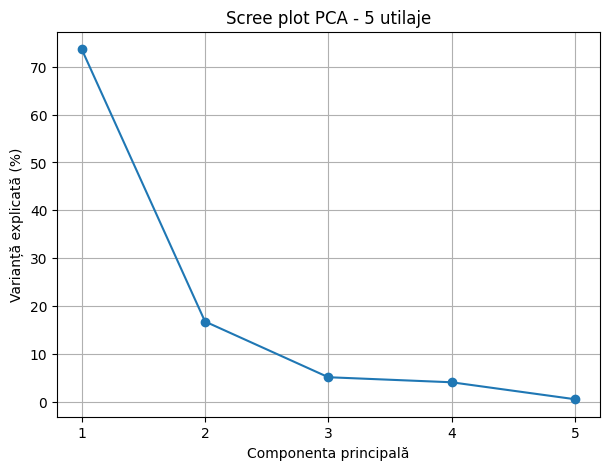

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(items_5) + 1),
    pca_5.explained_variance_ratio_ * 100,
    marker="o"
)
plt.xlabel("Componenta principală")
plt.ylabel("Varianță explicată (%)")
plt.title("Scree plot PCA - 5 utilaje")
plt.xticks(range(1, len(items_5) + 1))
plt.grid(True)
plt.show()

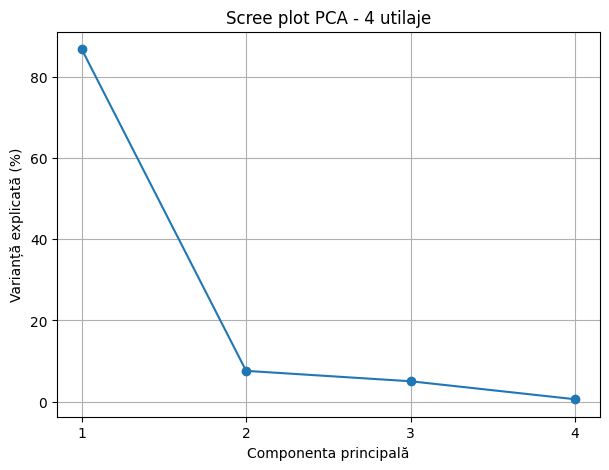

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(items_4) + 1),
    pca_4.explained_variance_ratio_ * 100,
    marker="o"
)
plt.xlabel("Componenta principală")
plt.ylabel("Varianță explicată (%)")
plt.title("Scree plot PCA - 4 utilaje")
plt.xticks(range(1, len(items_4) + 1))
plt.grid(True)
plt.show()

### 5. Density-Based Mechanization Index Construction

The final density-based mechanization index is constructed as the mean of the standardized machinery-density indicators for tractors, ploughs, mechanical seeders, and combine harvesters.

In [37]:
items_4 = [
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha"
]

for col in items_4:
    df[f"z_{col}"] = (df[col] - df[col].mean()) / df[col].std(ddof=1)

df["indice_mecanizare"] = df[[f"z_{col}" for col in items_4]].mean(axis=1, skipna=False)

### 6. Index Validation and Descriptive Analysis

#### 6.1 Distribution of the Mechanization Index

In [38]:
df["indice_mecanizare"].describe()

count    4.510000e+02
mean    -1.575483e-17
std      9.309870e-01
min     -9.809964e-01
25%     -6.839215e-01
50%     -3.546970e-01
75%      3.270385e-01
max      3.856129e+00
Name: indice_mecanizare, dtype: float64

In [39]:
df[["indice_mecanizare"] + [f"z_{col}" for col in items_4]].head()

,indice_mecanizare,z_tractoare_1000ha,z_pluguri_1000ha,z_semanatori_1000ha,z_combine_1000ha
0,0.325602,-0.137225,0.004986,0.728610,0.706037
1,0.415279,-0.038678,0.111669,0.764576,0.823547
2,0.339254,-0.075861,0.059948,0.652354,0.720574
3,0.288378,-0.105531,0.016013,0.564012,0.679018
4,0.376424,-0.059909,0.065414,0.671553,0.828635


#### 6.2 Highest and Lowest Index Values

In [40]:
df[["judet", "an", "indice_mecanizare",
    "tractoare_1000ha", "pluguri_1000ha",
    "semanatori_1000ha", "combine_1000ha"
]].sort_values("indice_mecanizare", ascending=False).head(10)

,judet,an,indice_mecanizare,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha
285,Maramures,2022,3.856129,519.185306,278.868885,50.327332,15.230042
284,Maramures,2021,3.740764,508.534459,275.167477,49.050197,14.637056
280,Maramures,2017,3.626486,457.108130,284.792670,47.496611,15.193306
283,Maramures,2020,3.475166,468.366465,270.224719,45.808124,13.915298
282,Maramures,2019,3.311574,443.138093,260.025652,44.121419,13.980333
281,Maramures,2018,3.199753,430.698644,253.055266,43.295099,13.639208
230,Harghita,2022,2.927381,475.026934,202.283990,32.148244,15.427710
278,Maramures,2015,2.708459,382.472532,221.991522,35.340427,13.582490
279,Maramures,2016,2.609261,368.109908,213.655287,36.011657,13.072440
241,Hunedoara,2022,2.550757,303.053410,208.533634,37.960415,15.151013


In [41]:
df[["judet", "an", "indice_mecanizare",
    "tractoare_1000ha", "pluguri_1000ha",
    "semanatori_1000ha", "combine_1000ha"
]].sort_values("indice_mecanizare", ascending=True).head(10)

,judet,an,indice_mecanizare,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha
196,Galati,2021,-0.980996,7.829696,5.523374,3.809666,1.008215
101,Buzau,2014,-0.939760,10.281228,10.088909,3.736049,1.229586
102,Buzau,2015,-0.937577,10.340819,10.136019,3.743112,1.257156
100,Buzau,2013,-0.935471,10.490262,10.243093,3.803844,1.251898
83,Braila,2018,-0.905070,7.420389,6.288008,4.844073,1.854348
81,Braila,2016,-0.903805,8.241244,7.161336,4.784955,1.782286
82,Braila,2017,-0.896993,8.054811,6.747469,4.994166,1.860212
244,Ialomita,2014,-0.894460,11.064330,8.347994,5.536903,1.389753
84,Braila,2019,-0.893428,7.566173,6.557767,5.063949,1.935387
85,Braila,2020,-0.890229,6.925726,6.106762,5.213640,2.002270


#### 6.3 County-Level Patterns

In [42]:
indice_judete = (
    df.groupby("judet")["indice_mecanizare"]
    .mean()
    .sort_values(ascending=False)
)

indice_judete.head(10), indice_judete.tail(10)

(judet
 Maramures          2.921165
 Harghita           2.189368
 Hunedoara          1.738369
 Brasov             1.729731
 Salaj              1.342090
 Sibiu              0.937662
 Caras-Severin      0.929327
 Covasna            0.649979
 Bistrita-Nasaud    0.378123
 Cluj               0.360792
 Name: indice_mecanizare, dtype: float64,
 judet
 Vaslui      -0.684345
 Botosani    -0.692709
 Calarasi    -0.738102
 Prahova     -0.746506
 Tulcea      -0.835761
 Galati      -0.848558
 Ialomita    -0.857104
 Constanta   -0.866492
 Buzau       -0.873485
 Braila      -0.881755
 Name: indice_mecanizare, dtype: float64)

#### 6.4 Temporal Evolution


In [43]:
indice_ani = (
    df.groupby("an")["indice_mecanizare"]
    .mean()
)

indice_ani

an
2012   -0.069345
2013   -0.050619
2014   -0.055345
2015   -0.022011
2016    0.003451
2017    0.079032
2018    0.043842
2019   -0.010363
2020    0.000722
2021    0.022199
2022    0.058438
Name: indice_mecanizare, dtype: float64

In [44]:
df.groupby("judet")[[
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha",
    "indice_mecanizare",
    "sup_totala_cultivata_ha"
]].mean().sort_values("indice_mecanizare", ascending=False).head(10)

,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha,indice_mecanizare,sup_totala_cultivata_ha
judet,,,,,,
Maramures,397.600421,237.138881,40.212037,13.190417,2.921165,22738.727273
Harghita,244.609806,126.665767,31.088529,21.757281,2.189368,19712.818182
Hunedoara,210.637510,147.870888,37.391983,11.441597,1.738369,29112.727273
Brasov,165.408921,129.197175,38.620075,14.775528,1.729731,28188.545455
Salaj,155.809362,134.777278,28.488735,12.221932,1.342090,35817.181818
Sibiu,135.598397,85.548721,31.657111,9.240642,0.937662,35044.909091
Caras-Severin,140.727463,114.220478,32.262626,6.141655,0.929327,50532.454545
Covasna,118.474567,82.461174,24.811374,8.217394,0.649979,39136.909091
Bistrita-Nasaud,106.540956,81.927272,20.275571,6.043425,0.378123,26871.818182


In [45]:
df.groupby("judet")[[
    "tractoare_1000ha",
    "pluguri_1000ha",
    "semanatori_1000ha",
    "combine_1000ha",
    "indice_mecanizare",
    "sup_totala_cultivata_ha"
]].mean().sort_values("indice_mecanizare", ascending=True).head(10)

,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha,indice_mecanizare,sup_totala_cultivata_ha
judet,,,,,,
Braila,8.294256,7.223474,5.233821,1.972660,-0.881755,315119.818182
Buzau,12.908477,12.708667,4.605222,1.657986,-0.873485,257024.272727
Constanta,8.433670,7.366076,5.766244,2.001120,-0.866492,422208.636364
Ialomita,11.940947,7.874617,5.416135,2.075410,-0.857104,321142.454545
Galati,13.157488,11.033507,5.745866,1.756398,-0.848558,256143.818182
Tulcea,12.775628,9.354925,5.193757,2.362374,-0.835761,226266.818182
Prahova,21.362984,12.921204,7.264460,2.306369,-0.746506,119810.545455
Calarasi,13.273823,10.212908,7.518730,3.006148,-0.738102,376783.000000
Botosani,19.993884,15.407400,8.148063,2.736597,-0.692709,213225.272727


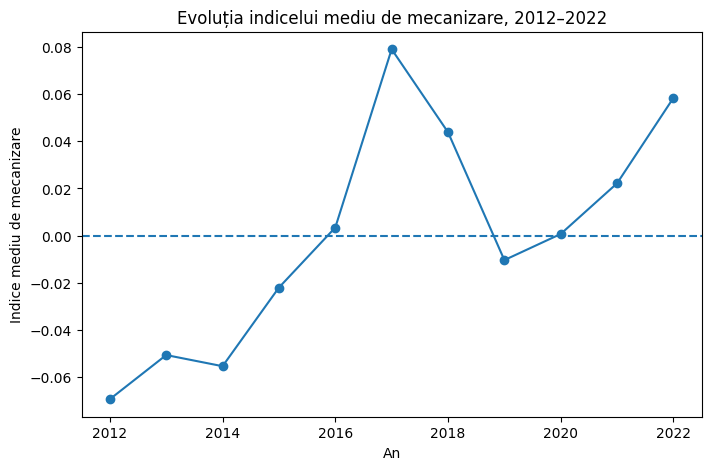

In [46]:
import matplotlib.pyplot as plt

indice_ani = df.groupby("an")["indice_mecanizare"].mean()

plt.figure(figsize=(8, 5))
plt.plot(indice_ani.index, indice_ani.values, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("An")
plt.ylabel("Indice mediu de mecanizare")
plt.title("Evoluția indicelui mediu de mecanizare, 2012–2022")
plt.show()